# PCA
Recall the steps to perform Principal Component Analysis (PCA):
1. **Standardise and Center The Data**: 
2. **Compute the Covariance Matrix**
3. **Calculate Eigenvalues and Eigenvectors**
4. **Select Principal Components**
5. **Transform the Data**: 
   - Project the original data onto the selected principal components to obtain the reduced dataset.


### load packages and data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import linalg
from tqdm.notebook import tqdm 

labels = pd.read_csv('mnist_labels.csv').to_numpy()
images = pd.read_csv('mnist_data.csv').to_numpy()
print(labels.shape)
print(images.shape)


(5000, 1)
(5000, 784)


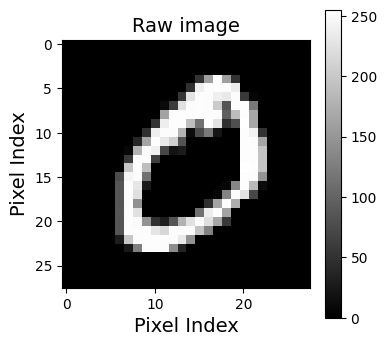

In [27]:
plt.figure(figsize=(4,4))
plt.xlabel('Pixel Index', size=14)
plt.ylabel('Pixel Index', size=14)
plt.title('Raw image', size=14)
plt.imshow(images[1].reshape(28,28), cmap='gray')
plt.colorbar()

# 1. Standardise the Data 

In [28]:
def standardise(X):
    """
    Standardise features.

    Parameters:
        X (np.array): Feature matrix.

    Returns:
        X_std (np.array): Standardised feature matrix
    """

    mu = np.mean(X, axis=0, keepdims=True)
    sigma = np.std(X, axis=0, keepdims=True)
    sigma[sigma == 0] = 1
    X_std = (X - mu) / sigma

    return X_std

In [29]:
# use first 500 images
X = standardise(images[:500])

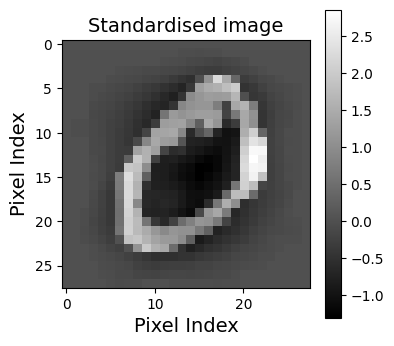

In [30]:
plt.figure(figsize=(4,4))
plt.xlabel('Pixel Index', size=14)
plt.ylabel('Pixel Index', size=14)
plt.title('Standardised image', size=14)
plt.imshow(X[1].reshape(28,28), cmap='gray')
plt.colorbar()

# 2. Compute the Covariance Matrix

In [31]:
def covariance_matrix(X):
    """
    Parameters:
      X (np.ndarray): Samples matrix, shape (N, p).

    Returns:
     The covariance matrix, shape (p, p).

    """
    return np.dot(X.T, X) / len(X)

covarience_matrix = covariance_matrix(X)

3. Calculate Eigenvalues and Eigenvectors

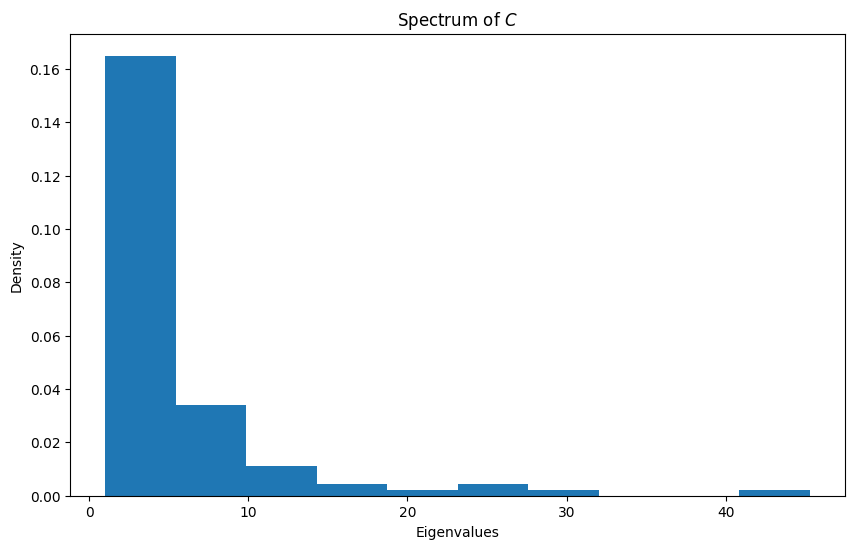

In [32]:
eigen = linalg.eigh(covarience_matrix)
eigenvalues = eigen.eigenvalues[::-1][0:100]
eigenvectors = eigen.eigenvectors[:, ::-1][:, 0:100]
plt.figure(figsize=(10,6))
plt.hist(eigenvalues, density=True)
plt.xlabel('Eigenvalues')
plt.ylabel('Density')
plt.title('Spectrum of $C$')
plt.show()

# 4. Select Principal Components

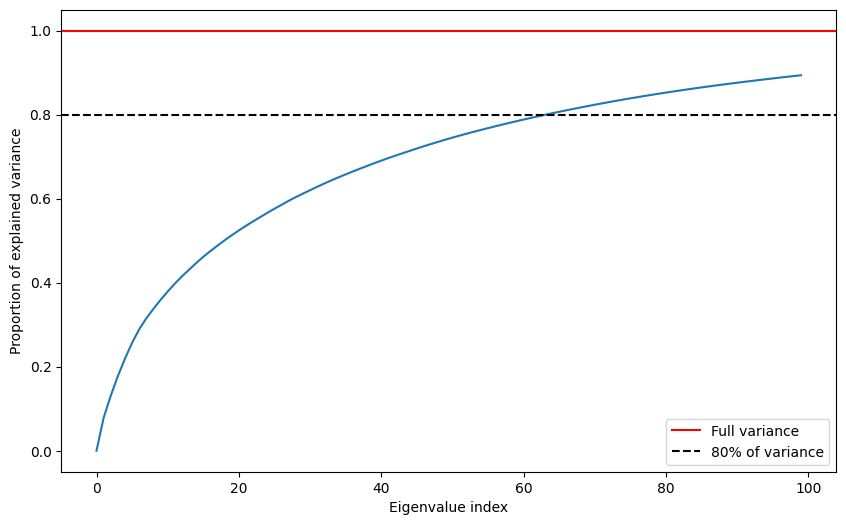

In [ ]:
all_eigenvalues, _ = np.linalg.eigh(covarience_matrix)
total_variance = abs(all_eigenvalues).sum()

explained_variances = [abs(eigenvalues[:j].sum()) / total_variance for j in range(100)]

plt.figure(figsize=(10,6))
plt.plot(np.arange(100), explained_variances)
plt.axhline(y = 1, color = 'r', linestyle = '-', label='Full variance')
plt.axhline(y = 0.8, color = 'k', linestyle = '--', label='80% of variance')
plt.xlabel('Eigenvalue index')
plt.ylabel('Proportion of explained variance')
plt.legend()
plt.show()

In [34]:
L = np.argmax(np.array(explained_variances) >= 0.8)
print(L)

64


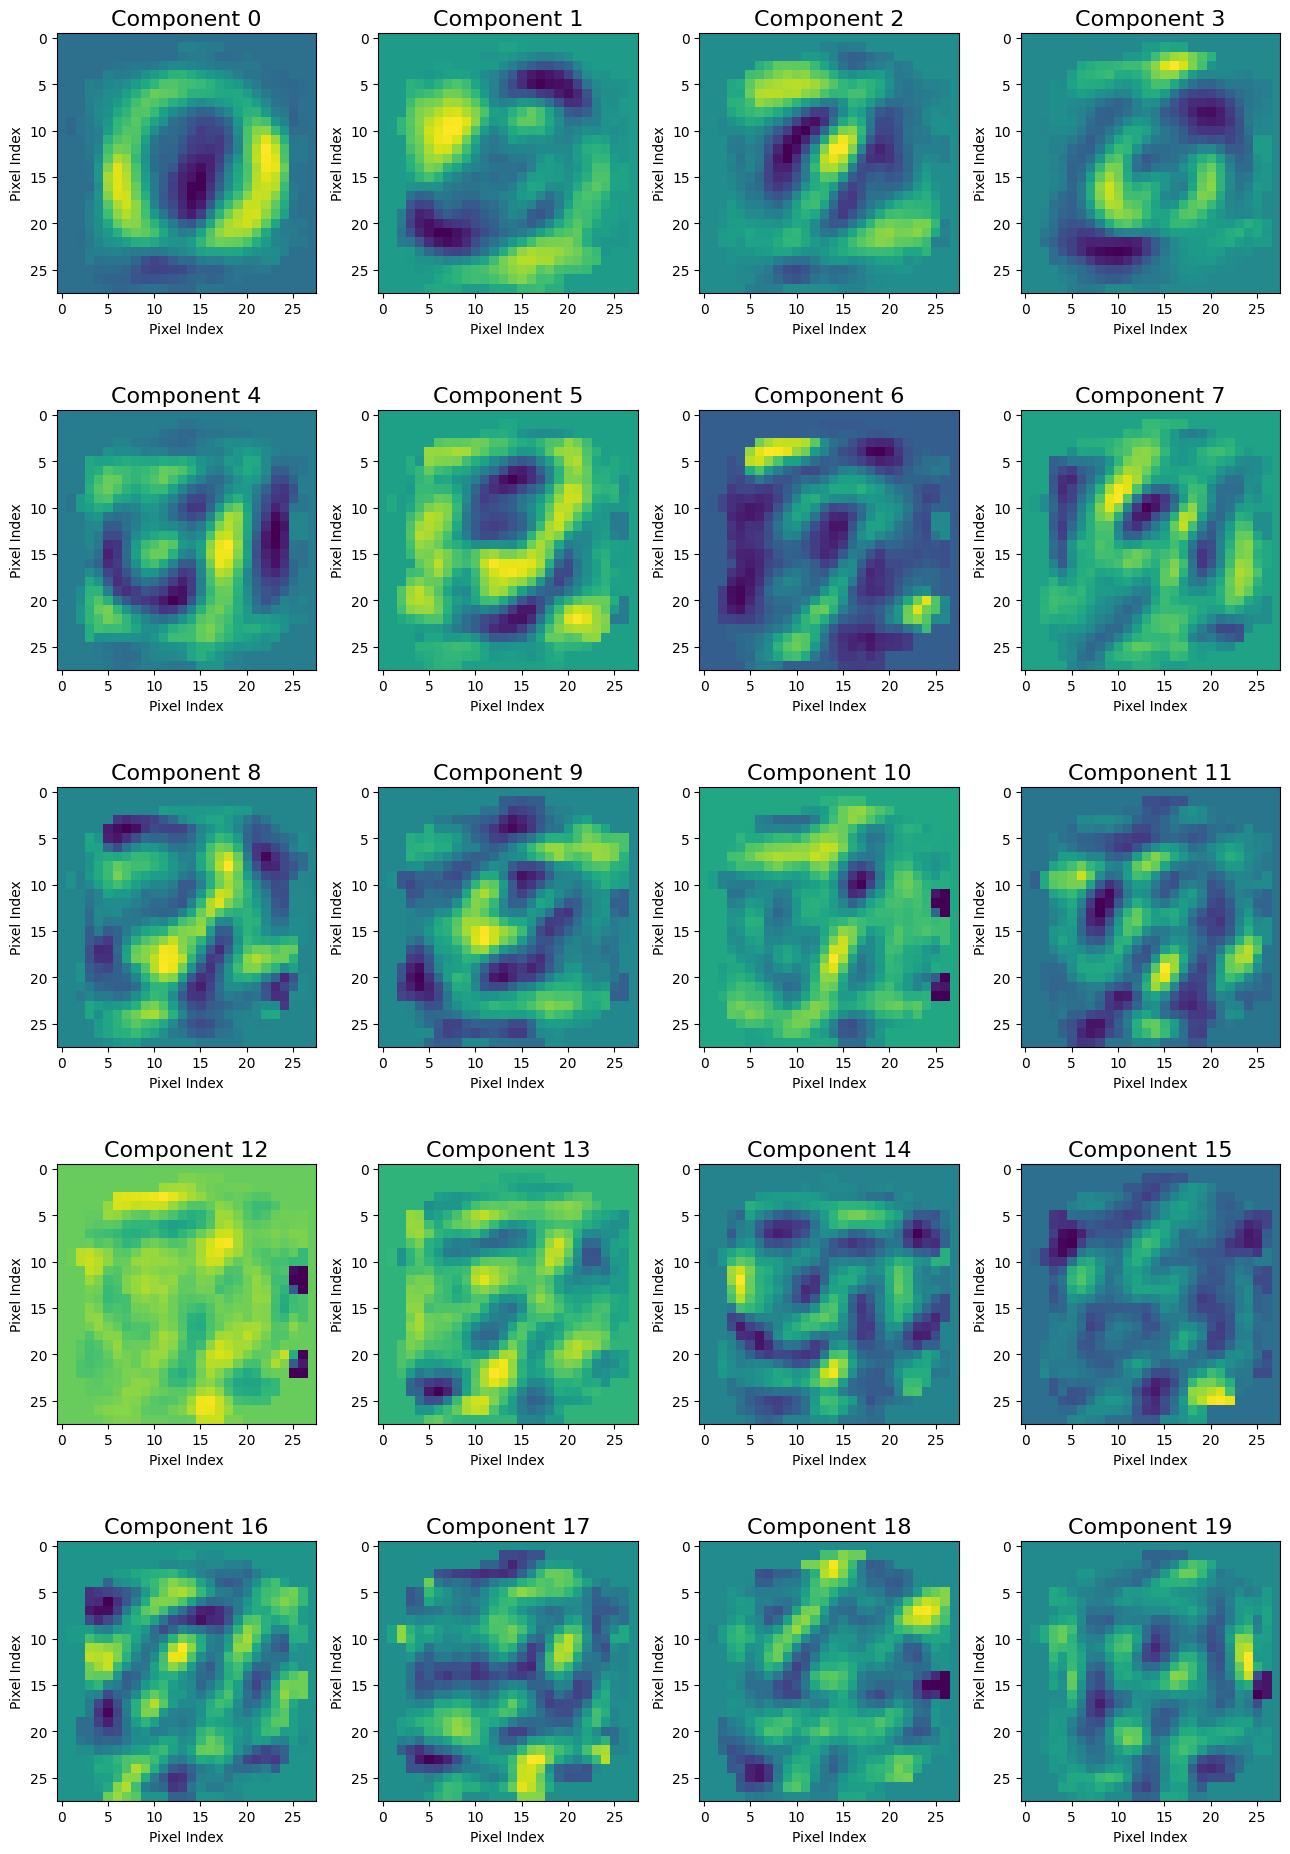

In [35]:
nrow = 5
ncol = 4
fig, axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(13,19)) 

for i, ax in enumerate(axs.reshape(-1)): 
    ax.imshow(eigenvectors[:,i].reshape([28,28])) 
    ax.set_title('Component '+str(i), size=16) 
    ax.set_xlabel('Pixel Index', size=10) 
    ax.set_ylabel('Pixel Index', size=10) 
plt.tight_layout()

# 5. Transform the Data

In [36]:
X_pca = X.dot(eigenvectors[:, :L])
print(X.shape)
print(X_pca.shape)

(500, 784)
(500, 64)


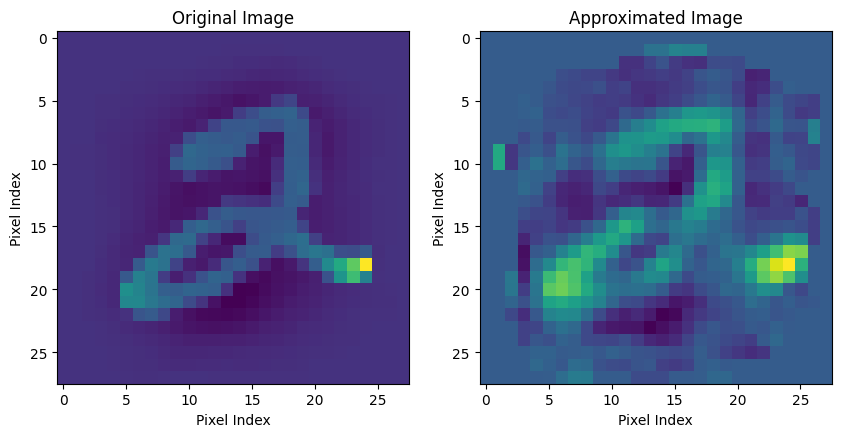

In [ ]:
index_image = 5

approximate_image = 0 
for y in range(L): 
    approximate_image += X_pca[index_image, y] * eigenvectors[:,y] 

fig, ax = plt.subplots(1, 2, figsize=(10,10))
ax[0].imshow(X[index_image].reshape([28,28]))
ax[0].set_title('Original Image')
ax[0].set_xlabel('Pixel Index')
ax[0].set_ylabel('Pixel Index')
ax[1].imshow(approximate_image.reshape([28,28]))
ax[1].set_xlabel('Pixel Index')
ax[1].set_ylabel('Pixel Index')
ax[1].set_title('Approximated Image');

# Example of downstream analysis

In [38]:
# choosse two digits only (5 and 7)
ind_5 = [i for i in range(len(labels)) if labels[i] == 5] 
ind_7 = [i for i in range(len(labels)) if labels[i] == 7] 
X_5 = images[ind_5, :] 
X_7 = images[ind_7, :]
X_subset = np.vstack((X_5, X_7))
n_5 = len(ind_5)
n_7 = len(ind_7)
n_datapoints = n_5 + n_7
X_subset_std = standardise(X_subset)


Find the first two principal components and plot them to visualize the data distribution in reduced dimensions.

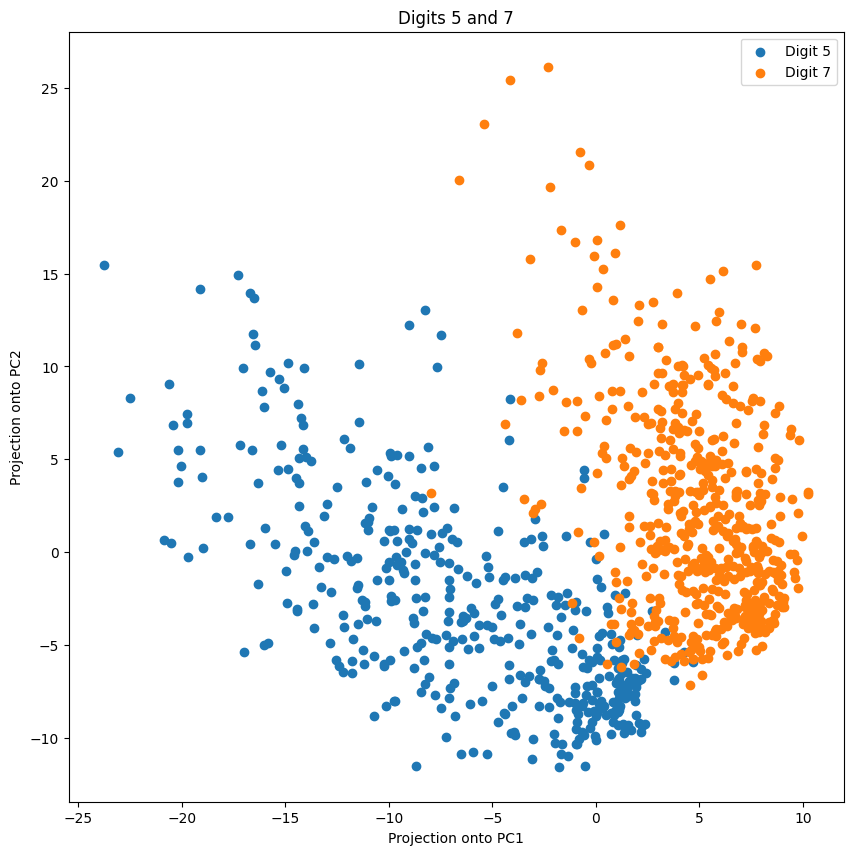

In [39]:
# covariance matrix
covarience_matrix_subset = covariance_matrix(X_subset_std)
# eigen decomposition
eigen_subset = linalg.eigh(covarience_matrix_subset)
eigenvalues_subset = eigen_subset.eigenvalues[::-1][0:2]
eigenvectors_subset = eigen_subset.eigenvectors[:, ::-1][:, 0:2]
# project data onto the first two principal components
X_subset_pca = X_subset_std.dot(eigenvectors_subset)


plt.figure(figsize=(10,10))
plt.scatter(X_subset_pca[:n_5, 0], X_subset_pca[:n_5, 1], label='Digit 5')
plt.scatter(X_subset_pca[n_5:n_datapoints, 0],
            X_subset_pca[n_5:n_datapoints, 1], label='Digit 7')
plt.legend()
plt.xlabel('Projection onto PC1')
plt.ylabel('Projection onto PC2')
plt.title('Digits 5 and 7')
plt.show()